<a href="https://colab.research.google.com/github/new2datasci/QKD/blob/main/decoy_state_v1031126.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


  Decoy-State QKD — Lim et al. 2013
  Simulating Eqs. (1)–(5) with numerical optimization

[1/4] Detailed breakdown at L=50km, nX=10^9 ...
DETAILED BREAKDOWN at L=50km, nX=10^9

OPTIMIZED PARAMETERS:
  µ1 (signal intensity)    = 0.8052
  µ2 (weak decoy)          = 0.1082
  µ3 (vacuum decoy, fixed) = 2.0000e-04
  p1 (signal prob)         = 0.9127  (91.27%)
  p2 (weak decoy prob)     = 0.0485  (4.85%)
  p3 (vacuum prob)         = 0.0388  (3.88%)
  qx (X-basis prob)        = 0.9999

CHANNEL:
  η_sys                    = 1.000e-02
  Total detection rate     = 7.668e-03
  Observed QBER            = 0.054%

DETECTION COUNTS (X basis, out of nX=1e+09):
  nX1 (from µ1 signal)     = 9.93e+08
  nX2 (from µ2 weak decoy) = 7.12e+06
  nX3 (from µ3 vacuum)     = 1.68e+04

POISSON WEIGHTS:
  τ0 (vacuum fraction)     = 0.490298
  τ1 (single-ph fraction)  = 0.333221

EQUATION OUTPUTS:
  Eq.(2) sx0               = 0.0000e+00  (vacuum events)
  Eq.(3) sx1               = 4.0125e+08  (single-photon event

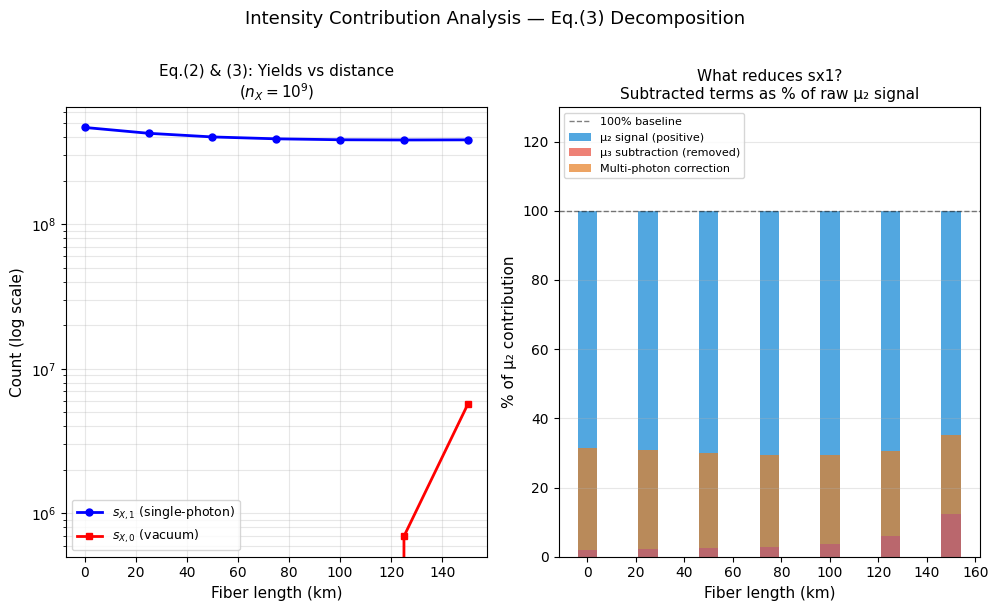

Saved: fig2_sx1_contributions.png

[3/4] Plotting µ2 sensitivity ...


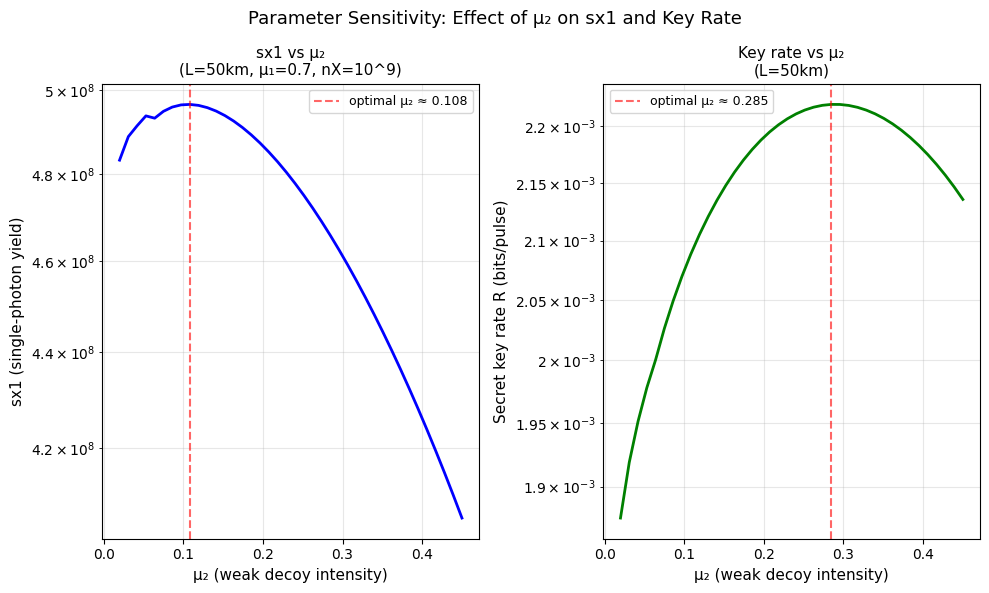

Saved: fig3_mu2_sensitivity.png

[4/4] Reproducing Figure 1 (key rate vs distance) ...
      This will take 3-5 minutes. Reduce nX_list to speed up.
  Computing nX = 10^4 ...
  Computing nX = 10^5 ...
  Computing nX = 10^6 ...
  Computing nX = 10^7 ...
  Computing nX = 10^8 ...
  Computing nX = 10^9 ...
  Computing asymptotic curve ...


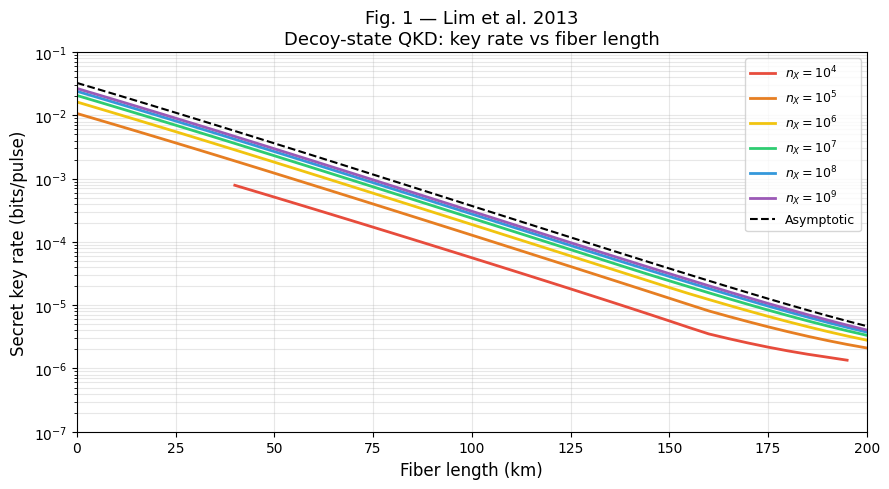

Saved: fig1_key_rate_vs_distance.png

All done! Check the saved .png files.


In [1]:
"""
=============================================================================
Decoy-State QKD Simulation — Lim et al. 2013
"Concise Security Bounds for Practical Decoy-State QKD"
Phys. Rev. A 89, 022307 (2014)
=============================================================================

WHAT THIS FILE DOES:
  1. Implements all five security equations (Eqs. 1–5) exactly as in the paper
  2. Simulates the fiber channel model (InGaAs APD + afterpulse + dark counts)
  3. Shows how sx1 (single-photon yield) is estimated from the three intensities
  4. Plots key rate vs fiber length for different post-processing block sizes nX
  5. Lets you explore how parameters affect each quantity

STRUCTURE:
  - Section 1: Fixed constants (from paper p.3)
  - Section 2: Channel model
  - Section 3: Equations 1–5
  - Section 4: Numerical optimizer (searches best µ1, µ2, p1, p2, qx)
  - Section 5: Intensity contribution analysis (where does sx1 come from?)
  - Section 6: Plots

HOW TO USE:
  - Run as-is to reproduce Figure 1 from the paper
  - Change parameters in Section 1 to explore different regimes
  - See "CHANGE ME" comments for the main knobs to turn

=============================================================================
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from math import factorial, exp, log, log2
from scipy.optimize import minimize
import warnings
warnings.filterwarnings("ignore")


# =============================================================================
# SECTION 1 — FIXED CONSTANTS (from paper p.3)
# =============================================================================
# These are the physical system parameters. They are FIXED in the paper
# and not optimized. Change them here to model a different system.

MU3    = 2e-4      # vacuum decoy intensity (≈ 0 photons/pulse)
ETA_B  = 0.10      # Bob's detector efficiency (InGaAs APD, 10%)
PDC    = 6e-7      # dark count probability per pulse
PAP    = 4e-2      # afterpulse probability
E_MIS  = 5e-3      # optical misalignment error rate
F_EC   = 1.16      # error correction inefficiency
KAPPA  = 1e-15     # security constant (εsec = κ · ℓ)
E_COR  = 1e-15     # correctness parameter εcor
ALPHA  = 0.2       # fiber attenuation coefficient (dB/km)

# =============================================================================
# SECTION 2 — CHANNEL MODEL
# =============================================================================

def eta_sys(L):
    """
    System transmittance = fiber loss × detector efficiency.
    η_sys = 10^(-α·L/10) × η_Bob
    """
    return 10 ** (-ALPHA * L / 10) * ETA_B


def detection_rate(mu, L):
    """
    Expected detection rate for intensity mu at distance L (km).
    Eq. from paper p.3:
      D_k = 1 - (1 - 2·pdc) · exp(-η_sys · µ_k)
      R_k = D_k · (1 + p_ap)
    Includes dark counts (pdc) and afterpulse (pap).
    """
    eta = eta_sys(L)
    Dk  = 1 - (1 - 2 * PDC) * exp(-eta * mu)
    Rk  = Dk * (1 + PAP)
    return Rk


def error_rate(mu, L):
    """
    Expected QBER for intensity mu at distance L (km).
    e_k = p_dc + e_mis · [1 - exp(-η_ch · µ_k)] + p_ap · D_k / 2
    Note: η_ch (channel only) used in error term, not η_sys.
    """
    eta_ch = 10 ** (-ALPHA * L / 10)
    eta    = eta_sys(L)
    Dk     = 1 - (1 - 2 * PDC) * exp(-eta * mu)
    return PDC + E_MIS * (1 - exp(-eta_ch * mu)) + PAP * Dk / 2


# =============================================================================
# SECTION 3 — EQUATIONS 1–5 FROM LIM ET AL. 2013
# =============================================================================

def tau(n, mu1, mu2, p1, p2):
    """
    τ_n: expected fraction of n-photon pulses in the total detection set.

    τ_n = Σ_{k∈{µ1,µ2,µ3}} p_k · e^{-µ_k} · µ_k^n / n!

    This is the Poisson weight for exactly n photons, averaged over
    the three intensity levels weighted by their pulse probabilities.
    """
    p3 = 1 - p1 - p2
    f  = factorial(n)
    return (
        p1 * exp(-mu1) * mu1**n +
        p2 * exp(-mu2) * mu2**n +
        p3 * exp(-MU3) * MU3**n
    ) / f


def npm(n_k, n_total, p_k, mu_k, sign, eps):
    """
    Finite-key corrected count estimate: n±_{X,k}

    n±_{X,k} = (e^µk / p_k) · [n_{X,k} ± δ(n_X, ε)]

    where δ = sqrt(n_X/2 · log(21/ε)) is the Hoeffding fluctuation term.

    sign = +1 for upper bound (n+), -1 for lower bound (n-)
    """
    delta = (n_total / 2.0 * log(21.0 / eps)) ** 0.5
    return (exp(mu_k) / p_k) * (n_k + sign * delta)


def h2(x):
    """Binary entropy function h(x) = -x·log2(x) - (1-x)·log2(1-x)"""
    x = max(1e-15, min(1 - 1e-15, x))
    return -x * log2(x) - (1 - x) * log2(1 - x)


def gamma(a, b, c, d):
    """
    γ function for finite-key phase error correction (Eq. 5).
    Accounts for statistical fluctuations when estimating phase error
    from Z-basis errors.
    """
    b = max(1e-10, min(1 - 1e-10, b))
    c = max(1, c)
    d = max(1, d)
    inner = log2((c + d) / (c * d * (1 - b) * b) / (a ** 2))
    return ((c + d) * (1 - b) * b / (c * d * log(2)) * max(inner, 0)) ** 0.5


def equation_2_sx0(nX1, nX2, nX3, nXt, mu1, mu2, p1, p2, eps):
    """
    Eq. (2): Lower bound on vacuum events sx0.

    sx0 ≥ τ0 · (µ2 · n⁻_{X,µ3} - µ3 · n⁺_{X,µ2}) / (µ2 - µ3)

    Physical meaning:
    - Vacuum events (0-photon pulses) click only due to dark counts
    - µ3 ≈ 0 so its detections are almost pure vacuum → pins down sx0
    - µ2 provides an upper correction term
    - τ0 = expected fraction of 0-photon pulses in the total mix
    """
    p3  = 1 - p1 - p2
    t0  = tau(0, mu1, mu2, p1, p2)
    nm3 = npm(nX3, nXt, p3,  MU3,  -1, eps)   # n⁻_{X,µ3}
    np2 = npm(nX2, nXt, p2,  mu2,  +1, eps)   # n⁺_{X,µ2}

    sx0 = t0 * (mu2 * nm3 - MU3 * np2) / (mu2 - MU3)
    return max(sx0, 0.0)


def equation_3_sx1(nX1, nX2, nX3, nXt, mu1, mu2, p1, p2, sx0, eps):
    """
    Eq. (3): Lower bound on single-photon events sx1.

    sx1 ≥ (µ1·τ1 / D) · [n⁻_{X,µ2} - n⁺_{X,µ3} - ((µ2²-µ3²)/µ1²)·(n⁺_{X,µ1} - sx0/τ0)]

    where D = µ1(µ2-µ3) - (µ2²-µ3²)

    Physical meaning:
    - Single-photon events are what carry the secret key
    - µ2 (weak decoy) is dominated by 0- and 1-photon pulses
    - µ3 (vacuum) pins down 0-photon contribution
    - The multi-photon correction subtracts events from n≥2 photons
    - τ1 = expected fraction of 1-photon pulses in the total mix
    """
    p3   = 1 - p1 - p2
    t0   = tau(0, mu1, mu2, p1, p2)
    t1   = tau(1, mu1, mu2, p1, p2)
    nm2  = npm(nX2, nXt, p2,  mu2,  -1, eps)   # n⁻_{X,µ2}
    np3  = npm(nX3, nXt, p3,  MU3,  +1, eps)   # n⁺_{X,µ3}
    np1  = npm(nX1, nXt, p1,  mu1,  +1, eps)   # n⁺_{X,µ1}

    denom = mu1 * (mu2 - MU3) - (mu2**2 - MU3**2)
    if denom <= 0:
        return 0.0

    multi_photon_correction = ((mu2**2 - MU3**2) / mu1**2) * (np1 - sx0 / t0)
    sx1 = (mu1 * t1 / denom) * (nm2 - np3 - multi_photon_correction)
    return max(sx1, 0.0)


def equation_4_vZ1(mZ1, mZ2, mZ3, mZt, mu1, mu2, p1, p2, eps):
    """
    Eq. (4): Upper bound on single-photon Z-basis errors vZ1.

    vZ1 ≤ τ1 · (n⁺_{Z,µ2} - n⁻_{Z,µ3}) / (µ2 - µ3)

    Physical meaning:
    - vZ1 counts single-photon error events in Z basis
    - Used to upper-bound the phase error rate φX (Eq. 5)
    - µ2 gives an upper bound, µ3 gives a lower correction
    """
    p3  = 1 - p1 - p2
    t1  = tau(1, mu1, mu2, p1, p2)
    mp2 = npm(mZ2, mZt, p2, mu2, +1, eps)   # n⁺_{Z,µ2}
    mm3 = npm(mZ3, mZt, p3, MU3, -1, eps)   # n⁻_{Z,µ3}

    vZ1 = t1 * (mp2 - mm3) / (mu2 - MU3)
    return max(vZ1, 0.0)


def equation_5_phiX(vZ1, sz1, sx1, eps):
    """
    Eq. (5): Upper bound on phase error rate φX.

    φX ≤ vZ1/sz1 + γ(ε, vZ1/sz1, sz1, sx1)

    Physical meaning:
    - Phase errors come from Eve's interaction with single-photon pulses
    - vZ1/sz1 is the raw phase error estimate from Z-basis statistics
    - γ corrects for finite-key statistical fluctuations
    - If φX → 0.5, single-photon channel is fully compromised → R = 0
    """
    if sz1 < 1:
        return 0.5
    phi = vZ1 / sz1 + gamma(eps, vZ1 / sz1, sz1, sx1)
    return min(phi, 0.5)


def equation_1_key_length(sx0, sx1, phiX, nXt, eobs, correction):
    """
    Eq. (1): Secret key length ℓ.

    ℓ = sx0 + sx1 - sx1·h(φX) - leak_EC - 6·log2(21/εsec) - log2(2/εcor)

    where:
      - sx0:        vacuum events (always secure, no phase error)
      - sx1:        single-photon events (partially secure)
      - sx1·h(φX):  privacy amplification cost for single photons
      - leak_EC:    error correction leakage = fEC · nX · h(eobs)
      - correction: finite-key security overhead

    Physical meaning:
    - Vacuum and single-photon events contribute to the key
    - Multi-photon events (n≥2) are entirely given to Eve (PNS attack)
    - Privacy amplification removes Eve's information about single-photon key
    """
    leak_EC = F_EC * nXt * h2(eobs)
    ell     = sx0 + sx1 - sx1 * h2(phiX) - leak_EC - correction
    return max(ell, 0.0)


# =============================================================================
# SECTION 4 — FULL KEY RATE COMPUTATION + OPTIMIZER
# =============================================================================

def compute_key_rate(mu1, mu2, p1, p2, qx, L, nX):
    """
    Compute secret key rate R = ℓ/N for given parameters.

    Parameters:
      mu1, mu2    : signal and weak-decoy intensities (mu3 fixed = 2e-4)
      p1, p2      : pulse probabilities for mu1 and mu2 (p3 = 1-p1-p2)
      qx          : probability Alice/Bob choose X basis (asymmetric BB84)
      L           : fiber length (km)
      nX          : post-processing block size (total X-basis detections)

    Returns:
      dict with R (key rate per pulse) and all intermediate quantities,
      or None if parameters are invalid / no key is possible.
    """
    p3 = 1 - p1 - p2

    # --- validity checks ---
    if p3 < 1e-4:                          return None  # p3 must be positive
    if mu1 <= mu2 + MU3 + 0.005:          return None  # need µ1 > µ2 > µ3
    if mu2 <= MU3 + 0.005:                return None
    if p1 <= 0 or p2 <= 0 or qx <= 0:    return None

    try:
        # --- detection counts (X basis) ---
        Rk1, Rk2, Rk3 = detection_rate(mu1, L), detection_rate(mu2, L), detection_rate(MU3, L)
        Rtot = p1 * Rk1 + p2 * Rk2 + p3 * Rk3
        if Rtot < 1e-20: return None

        # Distribute nX among intensities proportional to p_k * Rk
        nX1 = nX * p1 * Rk1 / Rtot
        nX2 = nX * p2 * Rk2 / Rtot
        nX3 = nX * p3 * Rk3 / Rtot
        nXt = nX  # by construction nX1+nX2+nX3 = nX

        eps = KAPPA  # use κ as per-term Hoeffding error

        # --- Eq. (2): sx0 ---
        sx0 = equation_2_sx0(nX1, nX2, nX3, nXt, mu1, mu2, p1, p2, eps)

        # --- Eq. (3): sx1 ---
        sx1 = equation_3_sx1(nX1, nX2, nX3, nXt, mu1, mu2, p1, p2, sx0, eps)
        if sx1 < 1: return None  # too few single-photon events

        # --- Eq. (4): vZ1 (Z-basis error events) ---
        ek1, ek2, ek3 = error_rate(mu1, L), error_rate(mu2, L), error_rate(MU3, L)
        mZ1 = nX * p1 * ek1 * Rk1 / Rtot
        mZ2 = nX * p2 * ek2 * Rk2 / Rtot
        mZ3 = nX * p3 * ek3 * Rk3 / Rtot
        mZt = mZ1 + mZ2 + mZ3
        vZ1 = equation_4_vZ1(mZ1, mZ2, mZ3, mZt, mu1, mu2, p1, p2, eps)

        # --- Eq. (5): φX ---
        sz1  = sx1  # single-photon Z events (same structure as X)
        phiX = equation_5_phiX(vZ1, sz1, sx1, eps)
        if phiX >= 0.4999: return None  # no information left in single-photon channel

        # --- Eq. (1): key length ---
        eobs       = (p1*ek1*Rk1 + p2*ek2*Rk2 + p3*ek3*Rk3) / Rtot
        correction = 6 * log2(21 / (KAPPA * nX)) + log2(2 / E_COR)
        ell        = equation_1_key_length(sx0, sx1, phiX, nXt, eobs, correction)
        if ell <= 0: return None

        # --- key rate R = ℓ / N ---
        # N = total pulses sent ≈ nX / (qx² · Rtot)
        N = nX / (qx**2 * Rtot)
        R = ell / N

        return {
            "R":       R,
            "ell":     ell,
            "N":       N,
            "sx0":     sx0,
            "sx1":     sx1,
            "vZ1":     vZ1,
            "phiX":    phiX,
            "eobs":    eobs,
            "nX1":     nX1,
            "nX2":     nX2,
            "nX3":     nX3,
            "Rtot":    Rtot,
            "tau0":    tau(0, mu1, mu2, p1, p2),
            "tau1":    tau(1, mu1, mu2, p1, p2),
        }
    except Exception:
        return None


def optimize_parameters(L, nX, n_restarts=5):
    """
    Numerically optimize {µ1, µ2, p1, p2, qx} to maximize key rate
    for given fiber length L and block size nX.

    This is what the paper does: parameters are NOT fixed inputs —
    they are the OUTPUT of optimization for each (L, nX) pair.

    Returns: (best_R, best_params_dict)
    """
    def decode(v):
        """Map unconstrained vector to physical parameters."""
        mu1 = max(0.05, min(1.40, v[0]))
        mu2 = max(0.01, min(0.55, v[1]))
        p1  = max(0.01, min(0.98, v[2]))
        p2  = max(0.01, min(min(0.49, 0.99 - v[2]), v[3]))
        qx  = max(0.50, min(0.9999, v[4]))
        return mu1, mu2, p1, p2, qx

    def objective(v):
        mu1, mu2, p1, p2, qx = decode(v)
        result = compute_key_rate(mu1, mu2, p1, p2, qx, L, nX)
        return -(result["R"] if result else 0.0)

    # Multiple starting points to avoid local minima
    starting_points = [
        [0.70, 0.15, 0.30, 0.20, 0.95],
        [0.50, 0.10, 0.60, 0.15, 0.95],
        [0.60, 0.12, 0.40, 0.25, 0.95],
        [0.80, 0.20, 0.50, 0.10, 0.95],
        [0.65, 0.18, 0.20, 0.45, 0.95],
    ]

    best_R      = 0.0
    best_params = None

    for x0 in starting_points[:n_restarts]:
        try:
            res = minimize(
                objective, x0,
                method="Nelder-Mead",
                options={"maxiter": 3000, "xatol": 1e-9, "fatol": 1e-11}
            )
            R = -res.fun
            if R > best_R:
                best_R      = R
                best_params = decode(res.x)
        except Exception:
            pass

    if best_params is None:
        return 0.0, None

    mu1, mu2, p1, p2, qx = best_params
    return best_R, {
        "mu1": mu1, "mu2": mu2, "mu3": MU3,
        "p1": p1,   "p2": p2,   "p3": 1 - p1 - p2,
        "qx": qx
    }


# =============================================================================
# SECTION 5 — INTENSITY CONTRIBUTION ANALYSIS
# =============================================================================
# This section answers: "where does sx1 come from?"
# We decompose sx1 into contributions from each pair of intensities.

def intensity_contributions(mu1, mu2, p1, p2, qx, L, nX):
    """
    Show how each intensity level contributes to sx1.

    The key insight: sx1 is estimated using a *pair* of intensities:
      - µ2 (weak decoy) provides most of the single-photon signal
      - µ3 (vacuum) subtracts the 0-photon background
      - µ1 (signal) provides the multi-photon correction

    We can track which term in Eq.(3) dominates.
    """
    p3  = 1 - p1 - p2
    eps = KAPPA

    Rk1 = detection_rate(mu1, L)
    Rk2 = detection_rate(mu2, L)
    Rk3 = detection_rate(MU3, L)
    Rtot = p1*Rk1 + p2*Rk2 + p3*Rk3
    if Rtot < 1e-20: return None

    nX1 = nX * p1 * Rk1 / Rtot
    nX2 = nX * p2 * Rk2 / Rtot
    nX3 = nX * p3 * Rk3 / Rtot
    nXt = nX

    t0 = tau(0, mu1, mu2, p1, p2)
    t1 = tau(1, mu1, mu2, p1, p2)

    sx0 = equation_2_sx0(nX1, nX2, nX3, nXt, mu1, mu2, p1, p2, eps)

    nm2 = npm(nX2, nXt, p2,  mu2,  -1, eps)
    np3 = npm(nX3, nXt, p3,  MU3,  +1, eps)
    np1 = npm(nX1, nXt, p1,  mu1,  +1, eps)

    denom = mu1 * (mu2 - MU3) - (mu2**2 - MU3**2)
    if denom <= 0: return None

    # Break down Eq.(3) term by term:
    term_mu2  = (mu1 * t1 / denom) * nm2        # positive: from weak decoy
    term_mu3  = (mu1 * t1 / denom) * (-np3)     # negative: vacuum subtraction
    multi_ph  = ((mu2**2 - MU3**2) / mu1**2) * (np1 - sx0/t0)
    term_corr = (mu1 * t1 / denom) * (-multi_ph) # negative: multi-photon correction

    sx1_total = max(term_mu2 + term_mu3 + term_corr, 0)

    return {
        "sx1_total":  sx1_total,
        "sx0":        sx0,
        "term_mu2":   term_mu2,      # contribution from µ2 counts
        "term_mu3":   term_mu3,      # vacuum subtraction (from µ3)
        "term_corr":  term_corr,     # multi-photon correction (from µ1)
        "nX1": nX1, "nX2": nX2, "nX3": nX3,
        "tau0": t0, "tau1": t1,
    }


# =============================================================================
# SECTION 6 — PLOTS
# =============================================================================

def plot_key_rate_vs_distance(nX_list=None, distances=None, figsize=(9, 5)):
    """
    Reproduce Figure 1 from the paper:
    Secret key rate vs fiber length for different block sizes nX.

    Each curve = optimized over {µ1, µ2, p1, p2, qx} at each distance.
    The dashed curve = asymptotic limit (nX → ∞).
    """
    if nX_list   is None: nX_list   = [1e4, 1e5, 1e6, 1e7, 1e8, 1e9]
    if distances is None: distances = list(range(0, 205, 5))

    colors = ["#e74c3c","#e67e22","#f1c40f","#2ecc71","#3498db","#9b59b6"]
    fig, ax = plt.subplots(figsize=figsize)

    for idx, nX in enumerate(nX_list):
        s    = int(round(np.log10(nX)))
        col  = colors[idx % len(colors)]
        Rs   = []
        Ls   = []

        print(f"  Computing nX = 10^{s} ...")
        for L in distances:
            R, _ = optimize_parameters(L, nX, n_restarts=4)
            if R > 0:
                Rs.append(R)
                Ls.append(L)

        if Ls:
            ax.semilogy(Ls, Rs, color=col, linewidth=2, label=f"$n_X = 10^{{{s}}}$")

    # Asymptotic curve (nX → ∞, effectively no finite-key penalty)
    Rs_inf = []
    Ls_inf = []
    print("  Computing asymptotic curve ...")
    for L in distances:
        R, _ = optimize_parameters(L, 1e15, n_restarts=3)
        if R > 0:
            Rs_inf.append(R)
            Ls_inf.append(L)
    if Ls_inf:
        ax.semilogy(Ls_inf, Rs_inf, "k--", linewidth=1.5, label="Asymptotic")

    ax.set_xlabel("Fiber length (km)", fontsize=12)
    ax.set_ylabel("Secret key rate (bits/pulse)", fontsize=12)
    ax.set_title("Fig. 1 — Lim et al. 2013\nDecoy-state QKD: key rate vs fiber length", fontsize=13)
    ax.set_xlim(0, 200)
    ax.set_ylim(1e-7, 1e-1)
    ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.savefig("fig1_key_rate_vs_distance.png", dpi=150)
    plt.show()
    print("Saved: fig1_key_rate_vs_distance.png")


def plot_sx1_contributions(L_list=None, nX=1e9, figsize=(10, 6)):
    """
    Show how sx1 is built up from the three intensities at different distances.

    For each distance, compute the optimized parameters and then decompose
    sx1 into its three constituent terms from Eq.(3):
      - Weak decoy (µ2) contribution  → positive
      - Vacuum subtraction (µ3)       → negative (reduces sx1)
      - Multi-photon correction (µ1)  → negative (removes n≥2 contamination)
    """
    if L_list is None: L_list = [0, 25, 50, 75, 100, 125, 150]

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    ax1, ax2  = axes

    sx1_vals, sx0_vals, Ls_valid = [], [], []
    t_mu2_vals, t_mu3_vals, t_corr_vals = [], [], []
    frac_mu2, frac_mu3, frac_corr = [], [], []

    for L in L_list:
        R, params = optimize_parameters(L, nX, n_restarts=4)
        if R == 0 or params is None: continue

        contrib = intensity_contributions(
            params["mu1"], params["mu2"],
            params["p1"],  params["p2"],
            params["qx"], L, nX
        )
        if contrib is None: continue

        Ls_valid.append(L)
        sx1_vals.append(contrib["sx1_total"])
        sx0_vals.append(contrib["sx0"])
        t_mu2_vals.append(contrib["term_mu2"])
        t_mu3_vals.append(abs(contrib["term_mu3"]))
        t_corr_vals.append(abs(contrib["term_corr"]))

        total_pos = contrib["term_mu2"]
        if total_pos > 0:
            frac_mu2.append(100)
            frac_mu3.append(abs(contrib["term_mu3"])  / total_pos * 100)
            frac_corr.append(abs(contrib["term_corr"]) / total_pos * 100)
        else:
            frac_mu2.append(0); frac_mu3.append(0); frac_corr.append(0)

    # Left plot: absolute sx0 and sx1 vs distance
    ax1.semilogy(Ls_valid, sx1_vals, "b-o", linewidth=2, markersize=5, label="$s_{X,1}$ (single-photon)")
    ax1.semilogy(Ls_valid, sx0_vals, "r-s", linewidth=2, markersize=5, label="$s_{X,0}$ (vacuum)")
    ax1.set_xlabel("Fiber length (km)", fontsize=11)
    ax1.set_ylabel("Count (log scale)", fontsize=11)
    ax1.set_title(f"Eq.(2) & (3): Yields vs distance\n($n_X = 10^{{{int(np.log10(nX))}}}$)", fontsize=11)
    ax1.legend(fontsize=9)
    ax1.grid(True, which="both", alpha=0.3)

    # Right plot: stacked bar showing where sx1 comes from
    width  = 8
    x      = np.array(Ls_valid)
    bars_mu2  = np.array(frac_mu2)
    bars_mu3  = np.array(frac_mu3)
    bars_corr = np.array(frac_corr)

    ax2.bar(x, bars_mu2,  width=width, label="µ₂ signal (positive)", color="#3498db", alpha=0.85)
    ax2.bar(x, bars_mu3,  width=width, bottom=0, label="µ₃ subtraction (removed)", color="#e74c3c", alpha=0.70)
    ax2.bar(x, bars_corr, width=width, bottom=bars_mu3, label="Multi-photon correction", color="#e67e22", alpha=0.70)
    ax2.axhline(100, color="black", linestyle="--", linewidth=1, alpha=0.5, label="100% baseline")
    ax2.set_xlabel("Fiber length (km)", fontsize=11)
    ax2.set_ylabel("% of µ₂ contribution", fontsize=11)
    ax2.set_title("What reduces sx1?\nSubtracted terms as % of raw µ₂ signal", fontsize=11)
    ax2.legend(fontsize=8, loc="upper left")
    ax2.grid(True, axis="y", alpha=0.3)
    ax2.set_ylim(0, 130)

    plt.suptitle("Intensity Contribution Analysis — Eq.(3) Decomposition", fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig("fig2_sx1_contributions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: fig2_sx1_contributions.png")


def plot_parameter_sensitivity(L=50, nX=1e9, figsize=(10, 6)):
    """
    Show how sx1 and R change as you vary µ2 (weak decoy intensity).

    µ2 is the most important tunable parameter:
      - Too small → vacuum correction overwhelms sx1 (bounds collapse)
      - Too large → multi-photon contamination grows
      - Sweet spot typically around µ2 ≈ 0.1–0.2 for µ1 ≈ 0.7
    """
    mu2_range = np.linspace(0.02, 0.45, 40)
    mu1       = 0.70
    p1        = 0.60
    p2_vals   = []
    sx1_vals  = []
    R_vals    = []

    # For each µ2, optimize p2 and qx while fixing µ1, p1
    for mu2 in mu2_range:
        best_R   = 0
        best_sx1 = 0
        for p2 in np.linspace(0.01, min(0.39, 0.99 - p1), 10):
            res = compute_key_rate(mu1, mu2, p1, p2, 0.95, L, nX)
            if res and res["R"] > best_R:
                best_R   = res["R"]
                best_sx1 = res["sx1"]
        R_vals.append(best_R)
        sx1_vals.append(best_sx1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    ax1.semilogy(mu2_range, [max(v, 1e-12) for v in sx1_vals],
                 "b-", linewidth=2)
    ax1.set_xlabel("µ₂ (weak decoy intensity)", fontsize=11)
    ax1.set_ylabel("sx1 (single-photon yield)", fontsize=11)
    ax1.set_title(f"sx1 vs µ₂\n(L={L}km, µ₁={mu1}, nX=10^{int(np.log10(nX))})", fontsize=11)
    ax1.grid(True, which="both", alpha=0.3)
    opt_idx = np.argmax(sx1_vals)
    ax1.axvline(mu2_range[opt_idx], color="red", linestyle="--", alpha=0.6,
                label=f"optimal µ₂ ≈ {mu2_range[opt_idx]:.3f}")
    ax1.legend(fontsize=9)

    ax2.semilogy(mu2_range, [max(v, 1e-12) for v in R_vals],
                 "g-", linewidth=2)
    ax2.set_xlabel("µ₂ (weak decoy intensity)", fontsize=11)
    ax2.set_ylabel("Secret key rate R (bits/pulse)", fontsize=11)
    ax2.set_title(f"Key rate vs µ₂\n(L={L}km)", fontsize=11)
    ax2.grid(True, which="both", alpha=0.3)
    opt_idx_R = np.argmax(R_vals)
    ax2.axvline(mu2_range[opt_idx_R], color="red", linestyle="--", alpha=0.6,
                label=f"optimal µ₂ ≈ {mu2_range[opt_idx_R]:.3f}")
    ax2.legend(fontsize=9)

    plt.suptitle("Parameter Sensitivity: Effect of µ₂ on sx1 and Key Rate", fontsize=13)
    plt.tight_layout()
    plt.savefig("fig3_mu2_sensitivity.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved: fig3_mu2_sensitivity.png")


def print_detailed_breakdown(L=50, nX=1e9):
    """
    Print a detailed human-readable breakdown of all intermediate quantities
    at a single operating point. Useful for understanding the equations.
    """
    print("=" * 65)
    print(f"DETAILED BREAKDOWN at L={L}km, nX=10^{int(np.log10(nX))}")
    print("=" * 65)

    R, params = optimize_parameters(L, nX, n_restarts=5)
    if R == 0 or params is None:
        print("No key possible at this operating point.")
        return

    mu1, mu2, p1, p2 = params["mu1"], params["mu2"], params["p1"], params["p2"]
    p3, qx = params["p3"], params["qx"]

    result = compute_key_rate(mu1, mu2, p1, p2, qx, L, nX)
    if result is None:
        print("Computation failed.")
        return

    print(f"\nOPTIMIZED PARAMETERS:")
    print(f"  µ1 (signal intensity)    = {mu1:.4f}")
    print(f"  µ2 (weak decoy)          = {mu2:.4f}")
    print(f"  µ3 (vacuum decoy, fixed) = {MU3:.4e}")
    print(f"  p1 (signal prob)         = {p1:.4f}  ({p1*100:.2f}%)")
    print(f"  p2 (weak decoy prob)     = {p2:.4f}  ({p2*100:.2f}%)")
    print(f"  p3 (vacuum prob)         = {p3:.4f}  ({p3*100:.2f}%)")
    print(f"  qx (X-basis prob)        = {qx:.4f}")

    print(f"\nCHANNEL:")
    print(f"  η_sys                    = {eta_sys(L):.3e}")
    print(f"  Total detection rate     = {result['Rtot']:.3e}")
    print(f"  Observed QBER            = {result['eobs']*100:.3f}%")

    print(f"\nDETECTION COUNTS (X basis, out of nX={nX:.0e}):")
    print(f"  nX1 (from µ1 signal)     = {result['nX1']:.2e}")
    print(f"  nX2 (from µ2 weak decoy) = {result['nX2']:.2e}")
    print(f"  nX3 (from µ3 vacuum)     = {result['nX3']:.2e}")

    print(f"\nPOISSON WEIGHTS:")
    print(f"  τ0 (vacuum fraction)     = {result['tau0']:.6f}")
    print(f"  τ1 (single-ph fraction)  = {result['tau1']:.6f}")

    print(f"\nEQUATION OUTPUTS:")
    print(f"  Eq.(2) sx0               = {result['sx0']:.4e}  (vacuum events)")
    print(f"  Eq.(3) sx1               = {result['sx1']:.4e}  (single-photon events)")
    print(f"  Eq.(4) vZ1               = {result['vZ1']:.4e}  (Z-basis errors)")
    print(f"  Eq.(5) φX                = {result['phiX']*100:.4f}%  (phase error rate)")

    print(f"\nKEY LENGTH (Eq. 1):")
    correction = 6 * log2(21 / (KAPPA * nX)) + log2(2 / E_COR)
    leak_EC    = F_EC * nX * h2(result['eobs'])
    privacy    = result['sx1'] * h2(result['phiX'])
    print(f"  sx0 + sx1                = {result['sx0'] + result['sx1']:.4e}")
    print(f"  - privacy amplification  = {privacy:.4e}  [sx1·h(φX)]")
    print(f"  - error correction       = {leak_EC:.4e}  [fEC·nX·h(eobs)]")
    print(f"  - security overhead      = {correction:.2f}   [finite-key terms]")
    print(f"  = key length ℓ           = {result['ell']:.4e}")
    print(f"  Total pulses N           = {result['N']:.4e}")
    print(f"  KEY RATE R = ℓ/N         = {result['R']:.4e} bits/pulse")
    print("=" * 65)


# =============================================================================
# MAIN — run everything
# =============================================================================

if __name__ == "__main__":

    print("\n" + "=" * 65)
    print("  Decoy-State QKD — Lim et al. 2013")
    print("  Simulating Eqs. (1)–(5) with numerical optimization")
    print("=" * 65)

    # ── 1. Detailed breakdown at one operating point ──────────────────
    print("\n[1/4] Detailed breakdown at L=50km, nX=10^9 ...")
    print_detailed_breakdown(L=50, nX=1e9)

    # ── 2. Intensity contribution analysis ───────────────────────────
    print("\n[2/4] Plotting intensity contributions to sx1 ...")
    plot_sx1_contributions(
        L_list=[0, 25, 50, 75, 100, 125, 150],
        nX=1e9
    )

    # ── 3. µ2 sensitivity ────────────────────────────────────────────
    print("\n[3/4] Plotting µ2 sensitivity ...")
    plot_parameter_sensitivity(L=50, nX=1e9)

    # ── 4. Figure 1: key rate vs distance ────────────────────────────
    # NOTE: this takes a few minutes — each point runs an optimization.
    # Reduce nX_list or distances for a faster run.
    print("\n[4/4] Reproducing Figure 1 (key rate vs distance) ...")
    print("      This will take 3-5 minutes. Reduce nX_list to speed up.")
    plot_key_rate_vs_distance(
        nX_list  = [1e4, 1e5, 1e6, 1e7, 1e8, 1e9],
        distances= list(range(0, 205, 5))
    )

    print("\nAll done! Check the saved .png files.")